**AI Accelerator Programme**

Generator AI and GANs

This notebook walks through the core ideas from Module 4 and gives you working code to go with them. The goal is straightforward: by the time you reach the end, you should have a GAN that trains on MNIST and produces recognizable handwritten digits.

Work through the sections in order the first time. Later, feel free to jump around and tweak things.

---
**What we cover:**
1. Generative vs. Discriminative models (conceptual)
2. A quick tour of generative model families (GANs, VAEs, Diffusion, Autoregressive)
3. GAN architecture — Generator, Discriminator, the minimax game
4. The training loop, common failure modes, and how to handle them
5. Full implementation: vanilla GAN on MNIST
6. Experiments to try on your own

**Prerequisites:** Python, basic PyTorch, some familiarity with neural networks.

## 0. Setup

Install and import everything we need. If you are on Google Colab, PyTorch is already available — just run the cell.

In [1]:

# !pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility — set seeds so results are consistent across runs.
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available; otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cpu


---
## 1. Generative vs. Discriminative Models

Most ML models you've used so far are **discriminative**: given an input X (e.g. an image), they predict a label Y (e.g. "cat" or "dog"). They learn the conditional distribution P(Y | X).

**Generative models** do something different. They learn the full joint distribution P(X, Y) — or just P(X) — which means they model the *structure of the data itself*. Once you have that, you can sample from it and create new, synthetic examples.

| | Discriminative | Generative |
|---|---|---|
| **Learns** | P(Y \| X) — decision boundary | P(X, Y) — data distribution |
| **Can classify?** | Yes | Yes (with extra work) |
| **Can generate new samples?** | No | Yes |
| **Examples** | Logistic Regression, CNN classifier, BERT | GAN, VAE, Diffusion, GPT |
| **Training difficulty** | Generally easier | Generally harder |

The key question a generative model asks is: *"What does the underlying data look like, and how was it produced?"* Once it answers that, it can produce new instances of the same kind.

---
## 2. The Four Main Generative Model Families

You will encounter four approaches regularly. Here is a plain-language summary of each.

### GANs (Generative Adversarial Networks)
Two networks compete: a Generator tries to create realistic data, a Discriminator tries to catch fakes. The competition forces the Generator to improve. Result: very sharp, realistic images. Downside: training can be unstable.

### VAEs (Variational Autoencoders)
Compress data into a structured "latent space", then reconstruct it. The latent space is smooth, so you can interpolate between points. Result: stable training, interpretable representations. Downside: outputs tend to be blurry.

### Diffusion Models
Gradually corrupt an image with noise, then learn to reverse the process. The model learns to denoise, and generation means starting from pure noise and denoising step by step. Result: state-of-the-art image quality (DALL-E, Stable Diffusion). Downside: slow to generate, computationally expensive.

### Autoregressive Models
Generate one token at a time, conditioning each new token on everything that came before. Result: excellent for sequences (text, audio). Downside: sequential generation is slow, and long-range coherence can be tricky.

For this module, we focus on **GANs**.

---
## 3. GAN Architecture

A GAN consists of two neural networks that are trained simultaneously in opposition to each other.

**Generator G:**
- Takes a random noise vector `z` (sampled from a standard normal distribution) as input.
- Outputs a synthetic sample (in our case, a 28×28 image that looks like a handwritten digit).
- Goal: produce samples that fool the Discriminator into thinking they are real.

**Discriminator D:**
- Takes an image as input (either real from the dataset, or fake from G).
- Outputs a single number in [0, 1]: the estimated probability that the input is *real*.
- Goal: correctly distinguish real images from fakes.

**The minimax objective:**
```
min_G  max_D  [ E[log D(x)] + E[log(1 - D(G(z)))] ]
```
- D wants to maximize this: output high values for real x, low values for fake G(z).
- G wants to minimize it: make D output high values for G(z) — i.e., fool D.

In practice both networks are updated with gradient descent (D maximizes by descending the negative, G minimizes directly).

In [2]:
# -------------------------
# Generator Network
# -------------------------
# Takes a noise vector of size z_dim and maps it to a 28x28 = 784-dimensional output.
# Tanh at the end squashes values to [-1, 1], matching how we will normalize the MNIST images.

class Generator(nn.Module):
    def __init__(self, z_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),   # 28*28 = 784
            nn.Tanh()              # output in [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


# -------------------------
# Discriminator Network

# Takes a flattened 784-dim image and outputs a single probability.
# LeakyReLU (instead of ReLU) helps gradients flow even for negative activations,
# which is important in the Discriminator to avoid the vanishing gradient problem.
# Dropout adds regularization so the Discriminator does not become overconfident too quickly.

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),     # negative slope = 0.2 is the standard choice
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()           # output = P(input is real)
        )

    def forward(self, x):
        return self.net(x)


# Instantiate both networks and move them to the chosen device.
Z_DIM = 100
G = Generator(z_dim=Z_DIM).to(device)
D = Discriminator().to(device)

print("Generator:")
print(G)
print("\nDiscriminator:")
print(D)

Generator:
Generator(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=784, bias=True)
    (5): Tanh()
  )
)

Discriminator:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


---
## 4. Data Loading

We use MNIST — 70,000 grayscale images of handwritten digits (0-9), each 28×28 pixels. It is the standard starting dataset for GANs because it is small, fast to train on, and the results are visually easy to judge.

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 478kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.73MB/s]


Training samples: 60000
Batches per epoch: 469


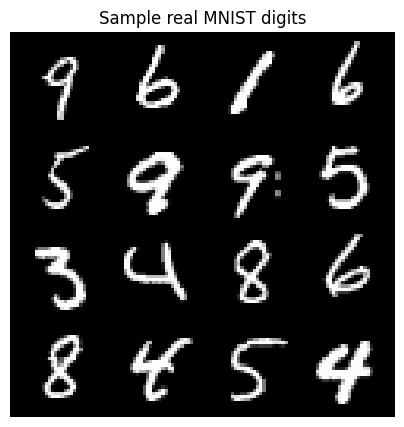

In [3]:
BATCH_SIZE = 128

# Normalize pixel values from [0, 255] to [-1, 1].
# This matches the Tanh output range of the Generator.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

# Show a small sample of real images so we know what we are aiming for.
real_batch, _ = next(iter(dataloader))
grid = make_grid(real_batch[:16], nrow=4, normalize=True)
plt.figure(figsize=(5, 5))
plt.title("Sample real MNIST digits")
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.show()

---
## 5. Loss Function and Optimizers

Both networks use **Binary Cross-Entropy (BCE)** loss, which is the standard choice for the original GAN formulation.

A few details worth noting:
- **Adam optimizer** with lr=2e-4 and betas=(0.5, 0.999) is a well-established default for GANs.
- **Label smoothing**: instead of using hard labels (1.0 for real, 0.0 for fake), we use 0.9 for real. This prevents the Discriminator from becoming overconfident, which leads to more useful gradients for the Generator.
- The Discriminator and Generator each have *separate* optimizers, because they are updated independently on alternating steps.

In [4]:
# BCE loss: -[y * log(p) + (1-y) * log(1-p)]
criterion = nn.BCELoss()

# Adam with the GAN-standard beta values
LR = 2e-4
optimizer_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# Label smoothing: real = 0.9 instead of 1.0
REAL_LABEL = 0.9
FAKE_LABEL = 0.0

print("Loss function and optimizers ready.")

Loss function and optimizers ready.


---
## 6. The Training Loop

Each training iteration has two stages:

**Stage 1 — Train the Discriminator:**
1. Feed a batch of real images; compute loss against label 1 (real).
2. Generate a batch of fakes from G; compute loss against label 0 (fake).
3. Add the two losses and back-propagate through D only.

**Stage 2 — Train the Generator:**
1. Generate a fresh batch of fakes.
2. Pass them through D but label them as *real* (label 1) — this is the adversarial trick. G wants D to be fooled.
3. Back-propagate the loss through G only (D's weights are not updated here).

We also keep a fixed noise vector to track visual progress across epochs.

In [ ]:
# Helper function: visualize a batch of generated images.
def show_generated(G, noise, epoch, save=False):
    G.eval()
    with torch.no_grad():
        fake_images = G(noise).view(-1, 1, 28, 28).cpu()
    grid = make_grid(fake_images, nrow=4, normalize=True)
    plt.figure(figsize=(5, 5))
    plt.title(f"Generated samples — Epoch {epoch}")
    plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    plt.axis("off")
    if save:
        plt.savefig(f"generated_epoch_{epoch:03d}.png", bbox_inches="tight")
    plt.show()
    G.train()


# Fixed noise — same 16 vectors every time, so we can see how the same "seeds" evolve.
fixed_noise = torch.randn(16, Z_DIM, device=device)

In [ ]:
NUM_EPOCHS = 30

# Lists to record loss history for plotting later.
loss_G_history = []
loss_D_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0

    for real_images, _ in dataloader:
        batch_size = real_images.size(0)

        # Flatten the images from (B, 1, 28, 28) to (B, 784).
        real_images = real_images.view(batch_size, -1).to(device)

        # ---- Train Discriminator ----
        # We update D more often than G (here 1:1, but you could try 2:1 or 5:1).

        optimizer_D.zero_grad()

        # Loss on real images: D should output ~1.
        real_labels = torch.full((batch_size, 1), REAL_LABEL, device=device)
        output_real = D(real_images)
        loss_D_real = criterion(output_real, real_labels)

        # Generate fakes and compute loss: D should output ~0.
        z = torch.randn(batch_size, Z_DIM, device=device)
        fake_images = G(z)                          # G(z) but no gradient needed for D update
        fake_labels = torch.full((batch_size, 1), FAKE_LABEL, device=device)
        output_fake = D(fake_images.detach())        # .detach() stops gradients flowing into G
        loss_D_fake = criterion(output_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # ---- Train Generator ----
        # G wants D to classify its fakes as real, so we use real_labels here.

        optimizer_G.zero_grad()

        z = torch.randn(batch_size, Z_DIM, device=device)
        fake_images = G(z)
        output = D(fake_images)                      # re-run through D (no detach — gradient flows back to G)
        real_labels_for_G = torch.full((batch_size, 1), 1.0, device=device)  # G wants D to output 1
        loss_G = criterion(output, real_labels_for_G)
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    # Average losses over all batches in this epoch.
    avg_loss_G = epoch_loss_G / len(dataloader)
    avg_loss_D = epoch_loss_D / len(dataloader)
    loss_G_history.append(avg_loss_G)
    loss_D_history.append(avg_loss_D)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | Loss D: {avg_loss_D:.4f} | Loss G: {avg_loss_G:.4f}")
        show_generated(G, fixed_noise, epoch)

print("Training complete.")

---
## 7. Inspecting the Results

### 7.1 Loss Curves

In a GAN that is training well, neither loss should go to zero. You want a *balance*:
- If D loss drops to nearly 0, the Discriminator is crushing the Generator and the Generator cannot learn (vanishing gradients).
- If G loss drops to nearly 0, the Generator has fully fooled D — but D is probably not learning either.

Some oscillation is normal. What you want to avoid is a sustained trend of one network completely dominating.

In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(loss_D_history, label="Discriminator loss", color="steelblue")
plt.plot(loss_G_history, label="Generator loss", color="tomato")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Final Generated Samples

Let's generate a larger grid of samples from random noise to see what the trained Generator has learned.

In [ ]:
G.eval()
with torch.no_grad():
    # Generate 64 samples from fresh random noise.
    sample_noise = torch.randn(64, Z_DIM, device=device)
    generated = G(sample_noise).view(-1, 1, 28, 28).cpu()

grid = make_grid(generated, nrow=8, normalize=True)
plt.figure(figsize=(10, 10))
plt.title("64 generated samples after training")
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.show()

---
## 8. Common Failure Modes (and Fixes)

GANs are notorious for being tricky to train. Here are the three problems you are most likely to encounter.

### Mode Collapse
The Generator learns to produce only a few types of output (e.g., only one or two digits) because those reliably fool the current Discriminator. The output grid will look repetitive.

**Fixes:** Minibatch discrimination, Wasserstein GAN (WGAN), unrolled GANs.

### Training Instability
Losses oscillate wildly or diverge. One network gets too far ahead of the other.

**Fixes:** Lower learning rates, spectral normalization on D, gradient penalty (as in WGAN-GP).

### Vanishing Gradients
The Discriminator becomes too accurate early on. Since D's output is always near 0 for fake images, the gradient that reaches G is nearly zero and it stops improving.

**Fixes:** Label smoothing (already in our code), feature matching, historical averaging.

In [ ]:
# Quick diagnostic: check the Discriminator's average confidence on real vs. fake images.
# Ideally both should hover near 0.5 in a balanced training run.

G.eval()
D.eval()

with torch.no_grad():
    sample_real, _ = next(iter(dataloader))
    sample_real = sample_real.view(sample_real.size(0), -1).to(device)
    d_real = D(sample_real).mean().item()

    z = torch.randn(BATCH_SIZE, Z_DIM, device=device)
    fake = G(z)
    d_fake = D(fake).mean().item()

print(f"D(real) = {d_real:.3f}  (want ~0.5 in a balanced GAN)")
print(f"D(fake) = {d_fake:.3f}  (want ~0.5 in a balanced GAN)")

G.train()
D.train()

---
## 9. Experiments to Try

Once the baseline is working, here are concrete things to change and observe.

### 9.1 Vary the Latent Dimension
Change `Z_DIM` from 100 to 10 or 200. A very small latent space may produce mode collapse; a very large one may slow convergence.

In [ ]:
# Interpolate between two points in latent space.
# If the Generator has learned a smooth distribution, the output should change gradually.

G.eval()
with torch.no_grad():
    z1 = torch.randn(1, Z_DIM, device=device)
    z2 = torch.randn(1, Z_DIM, device=device)

    # Create 8 equally-spaced steps between z1 and z2.
    steps = 8
    alphas = torch.linspace(0, 1, steps, device=device).unsqueeze(1)  # shape (steps, 1)
    interpolated = (1 - alphas) * z1 + alphas * z2                    # shape (steps, Z_DIM)
    interp_images = G(interpolated).view(-1, 1, 28, 28).cpu()

grid = make_grid(interp_images, nrow=steps, normalize=True)
plt.figure(figsize=(12, 2))
plt.title("Latent space interpolation (z1 → z2)")
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.show()

### 9.2 Turn Off Label Smoothing
Re-run training with `REAL_LABEL = 1.0` instead of 0.9. Do the loss dynamics change? Does the Discriminator become overconfident?

### 9.3 Change the Architecture
Try adding a third hidden layer to the Generator or Discriminator. Try replacing `ReLU` with `GELU`. Does image quality improve or get worse at the same number of epochs?

### 9.4 Add Noise to Discriminator Inputs
A classic stabilization trick is to add small Gaussian noise to the real images before passing them to D. Uncomment the line in the training loop to try it.

In [ ]:
# Example: adding instance noise to real images before D sees them.
# noise_scale = 0.05
# real_images_noisy = real_images + noise_scale * torch.randn_like(real_images)
# output_real = D(real_images_noisy)

# This is intentionally left as a snippet — paste it into the training loop to experiment.
print("Snippet ready — incorporate into the training loop above to test.")

---
## 10. GAN Variants — Brief Notes

The architecture we built is called a **vanilla GAN** (sometimes MLP-GAN). Once you have this working, the natural next steps are:

| Variant | Key Idea | When to Use |
|---|---|---|
| **DCGAN** | Replace linear layers with strided convolutions | Most image generation tasks |
| **WGAN / WGAN-GP** | Replace BCE loss with Wasserstein distance | When training is unstable or you see mode collapse |
| **Conditional GAN (CGAN)** | Feed class labels into both G and D | When you want to control what is generated |
| **CycleGAN** | Two G–D pairs + cycle consistency loss | Image-to-image translation without paired data |
| **StyleGAN** | Separate style/content via AdaIN, progressive training | Photorealistic face or texture generation |
| **Pix2Pix** | Conditional GAN with U-Net G and PatchGAN D | Image translation with paired data |

For the Nigerian pattern generation project (Project A), **DCGAN** is the recommended starting point, with **CycleGAN** as a stretch goal for unpaired style transfer between pattern types.

---
## 11. Assignment Checklist

Use this cell as a reference for the Week 9–10 deliverables.

- [ ] Decide on a project direction (A–E from the slide deck).
- [ ] Identify or collect a dataset relevant to your chosen direction.
- [ ] Implement a working GAN: Generator + Discriminator + training loop (this notebook gives you the baseline).
- [ ] Run at least two experiments varying architecture or hyperparameters. Document what changed.
- [ ] Save and plot loss curves. Note any failure modes you encountered and how you addressed them.
- [ ] Prepare a 5-minute progress demo for Week 10 — show generated samples, loss curves, and what you plan to improve.

**Practical tip from the module:** Start with a working vanilla GAN on MNIST (what you have here) before scaling to your target dataset. It is much easier to debug on a small, well-understood dataset.

---
## 12. A Note on Ethics

Generative models are powerful, and that comes with responsibility. A few things to keep in mind as you build:

**Deepfakes and misinformation.** The same technique that generates fabric patterns can generate convincing fake faces or voices. In Nigeria's electoral context, AI-generated disinformation is a real and growing concern. Think carefully about what you build and how it could be misused.

**Copyright and dataset provenance.** Models inherit biases and legal issues from their training data. If you are scraping images to build a dataset, check the licensing. Prefer datasets with permissive licenses (Creative Commons, public domain).

**Disclosure.** If you deploy a generative model in a product, consider making it clear to users when content is AI-generated. The C2PA standard and watermarking are emerging tools for content provenance.

These are not afterthoughts — they are part of building responsibly from the start.